HOUSE PRICE PREDICTION USING LINEAR REGRESSION

[STEP 1] Loading Dataset...
Dataset loaded successfully!
Shape: (545, 13)

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes

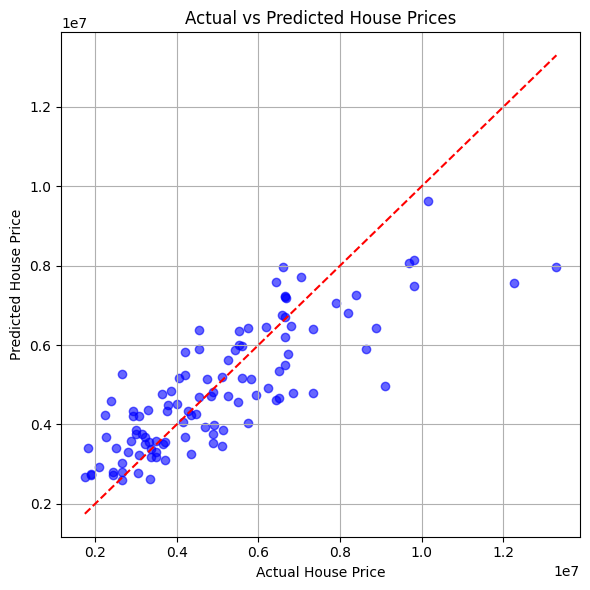

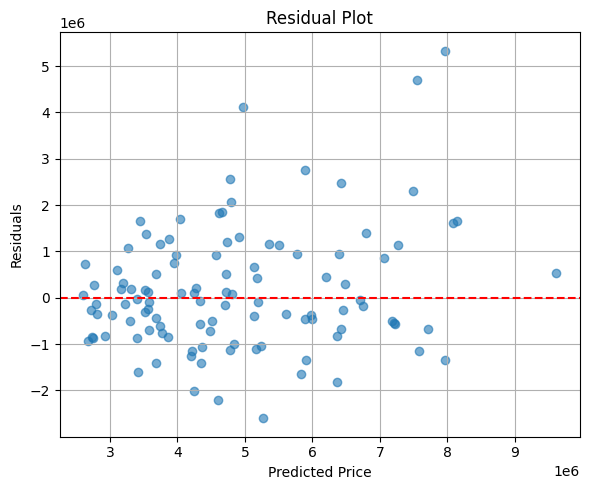


[STEP 9] Model Interpretation...

Top Influencing Features:
            Feature    Coefficient
2         bathrooms  521879.027748
0              area  519552.416340
8   airconditioning  365157.393851
3           stories  349251.438906
10         prefarea  266656.351993

PROJECT SUMMARY & INSIGHTS

• Linear Regression successfully trained on housing data
• R² Score indicates how well features explain price variation
• RMSE shows average prediction error
• Actual vs Predicted plot validates model performance

BUSINESS APPLICATIONS:
• Property price estimation
• Real estate investment decisions
• Automated valuation systems
• Market trend analysis


✓ HOUSE PRICE PREDICTION PROJECT COMPLETED SUCCESSFULLY!!!


In [3]:
# ===========================================================
# House Price Prediction Project - Oasis Infobyte Internship 
# Project -  Predicting House Prices with Linear Regression
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("HOUSE PRICE PREDICTION USING LINEAR REGRESSION")
print("="*70)

# ============================================================
# STEP 1: DATA COLLECTION
# ============================================================
print("\n[STEP 1] Loading Dataset...")

df = pd.read_csv("Housing.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# ============================================================
# STEP 2: DATA EXPLORATION & CLEANING
# ============================================================
print("\n[STEP 2] Data Exploration & Cleaning...")

print("\nMissing Values:")
print(df.isnull().sum())

# Convert categorical Yes/No columns to numeric
binary_cols = ['mainroad', 'guestroom', 'basement', 
               'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot encoding for furnishingstatus
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print("Categorical variables encoded successfully")

# ============================================================
# STEP 3: FEATURE SELECTION
# ============================================================
print("\n[STEP 3] Feature Selection...")

X = df.drop('price', axis=1)
y = df['price']

print("Features:", X.shape[1])
print("Target variable: price")

# ============================================================
# STEP 4: TRAIN-TEST SPLIT
# ============================================================
print("\n[STEP 4] Splitting Data...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

# ============================================================
# STEP 5: FEATURE SCALING
# ============================================================
print("\n[STEP 5] Feature Scaling...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")

# ============================================================
# STEP 6: MODEL TRAINING (LINEAR REGRESSION)
# ============================================================
print("\n[STEP 6] Training Linear Regression Model...")

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model training completed")

# ============================================================
# STEP 7: MODEL EVALUATION
# ============================================================
print("\n[STEP 7] Model Evaluation...")

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R²): {r2:.4f}")

# ============================================================
# STEP 8: VISUALIZATION
# ============================================================
print("\n[STEP 8] Visualization...")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=300)
plt.show()

# Residual plot
plt.figure(figsize=(6,5))
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.tight_layout()
plt.savefig("residual_plot.png", dpi=300)
plt.show()

# ============================================================
# STEP 9: INTERPRETATION
# ============================================================
print("\n[STEP 9] Model Interpretation...")

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\nTop Influencing Features:")
print(coefficients.head())

# ============================================================
# STEP 10: SUMMARY & INSIGHTS
# ============================================================
print("\n" + "="*70)
print("PROJECT SUMMARY & INSIGHTS")
print("="*70)

print(f"""
• Linear Regression successfully trained on housing data
• R² Score indicates how well features explain price variation
• RMSE shows average prediction error
• Actual vs Predicted plot validates model performance

BUSINESS APPLICATIONS:
• Property price estimation
• Real estate investment decisions
• Automated valuation systems
• Market trend analysis
""")

print("\n✓ HOUSE PRICE PREDICTION PROJECT COMPLETED SUCCESSFULLY!!!")
